## Corporate clustering prototype
This notebook analyses the `champions_group_data.csv` dataset. The goal is to build a prototype system that helps users derive actionable insights from company-level data by analysing firmographic, operational, and organizational attributes.

We will follow these steps:
1.  **Data Checking & Cleaning**: Load the data, check for missing values, and remove duplicates.
2.  **Exploratory Data Analysis (EDA)**: Investigate the features, their distributions, and their relationships with each other.
3.  **Preprocessing & Modeling**: Prepare the data for unsupervised modelling, using K-Means and Hierarchical Clustering to find natural groups.
4. **Cluster Interpretation**: Using Radar Charts to explain why a group exists.
5. **Building the tool**: Building a tool easily accesible for users to gain insights from big data.

## 1. Importing necessary package and getting data

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors 

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score

import pickle
import warnings
warnings.filterwarnings('ignore') 

sns.set(style="whitegrid")

In [74]:
data = pd.read_csv('../data/champions_group_data.csv')

## 2. Data Checking & Cleaning

Before our data analysis, data checking and cleaning is a crucial step. We have to ensure that the data processed is cleaned such as no missing values and no duplicates.

### 2.1 Initial Check of Raw Dataset

In [75]:
# Check initial shape of dataset
data.shape

(8559, 72)

After loading the data, the `.shape` command tells us we have 8559 rows (company sites) and 72 columns (variables).

### 2.2 Check for duplicates

In [76]:
# Check for duplicates
data.duplicated().sum()

0

We found 0 duplicated rows and hence every entry in our dataset is unique.

### 2.3 Dropping unimportant columns

Since there are 72 columns, we will be analysing and dropping some columns first before doing Exploratory Data Analysis.

In [77]:
def audit_data_quality(df):
    summary_data = []
    
    for col in df.columns:
        missing_pct = df[col].isnull().mean() * 100
        
        unique_count = df[col].nunique()
        
        value_counts_norm = df[col].value_counts(normalize=True, dropna=True)
        if not value_counts_norm.empty:
            top_val = value_counts_norm.index[0]
            dominance_pct = value_counts_norm.iloc[0] * 100
        else:
            top_val = "Empty"
            dominance_pct = 100.0
            
        summary_data.append({
            'Column': col,
            'Missing (%)': round(missing_pct, 2),
            'Unique Values': unique_count,
            'Top Value': str(top_val)[:30],  
            'Dominance (%)': round(dominance_pct, 2),
            'Type': df[col].dtype
        })
    
    quality_df = pd.DataFrame(summary_data)

    useless_cols = quality_df[quality_df['Dominance (%)'] > 97]['Column'].tolist()
    
    high_missing_cols = quality_df[
        (quality_df['Missing (%)'] > 70)
    ]['Column'].tolist()
    
    return quality_df, list(set(useless_cols + high_missing_cols))

quality_report, suggested_drops = audit_data_quality(data)

print("Columns with > 97% Dominance:")
print(quality_report[quality_report['Dominance (%)'] > 97].sort_values(by='Dominance (%)', ascending=False))

print("\nColumns with > 70% Missing Values:")
missing_series = quality_report.set_index('Column')['Missing (%)']
print(missing_series[missing_series > 70].sort_values(ascending=False))

print(f"\nSuggested drops ({len(suggested_drops)} columns)")
print(suggested_drops)

Columns with > 97% Dominance:
                              Column  Missing (%)  Unique Values  \
10                            Region         0.00              1   
49          Registration Number Type        99.91              1   
51  Company Status (Active/Inactive)         0.00              1   
58              Manufacturing Status        96.95              1   
59                   Fiscal Year End         0.01              1   
70                    No. of Servers        39.13              3   
8                            Country         0.00              3   
68                    No. of Laptops         7.47              3   
12                    Ownership Type        12.64              5   
67                   No. of Desktops         3.98              3   
34             Parent Country/Region         0.00              9   
41      Global Ultimate Country Name         0.00             14   
71            No. of Storage Devices        40.11              4   

                 

We will proceed with dropping `Region`, `Company Status`, and `Fiscal Year End`. These features exhibit near-zero variance (almost 100% identical values), meaning they offer no discriminatory power for our analysis.

Additionally, we will remove columns with >70% missing data. Given the high sparsity, these features lack critical information, and statistical imputation would likely introduce significant noise rather than recover meaningful signals.

However, despite statistical skew or missingness, we will explicitly retain high-value commercial indicators. These includes the `Country`, `Parent Country/Region`, `Ownership type` columns require more analysis since they may be useful for a data buyer who is interested in companies located in other countries apart from the majority which is China or a company belonging to public sector etc.

Furthermore, IT Infrastructure columns such as the `No. of Desktops`, `No. of Servers` may be a proxy for "Digital Maturity. Hence, even if sparse, the presence of this data indicates a tech-forward company, which is a key selling point for data buyers. Thus, we will not remove them as well.

In [78]:
cols_to_drop = set(suggested_drops) - {'Country', 'Parent Country/Region', 'No. of Desktops', 'No. of Laptops', 'No. of Servers', 'No. of Storage Devices'}
cols_to_drop = list(cols_to_drop)
print(f"\nFinal columns to drop ({len(cols_to_drop)} columns):")
print(cols_to_drop)


Final columns to drop (21 columns):
['Is Domestic Ultimate', 'Is Headquarters', 'ISIC Rev 4 Code', 'Ticker', 'Lattitude', 'ANZSIC Description', 'Manufacturing Status', 'Ownership Type', 'Phone Number', 'Company Status (Active/Inactive)', 'NACE Rev 2 Code', 'Website', 'NACE Rev 2 Description', 'ISIC Rev 4 Description', 'Global Ultimate Country Name', 'ANZSIC Code', 'Fiscal Year End', 'Longitude', 'Region', 'Registration Number Type', 'Franchise Status']


In [79]:
dropped_data = data.drop(columns=cols_to_drop)

In [80]:
dropped_data.shape

(8559, 51)

## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

To explore the variables on its own and examine its distribution and analyse its patterns. We will be doing this for selected variables. 

#### 3.1.1 Country

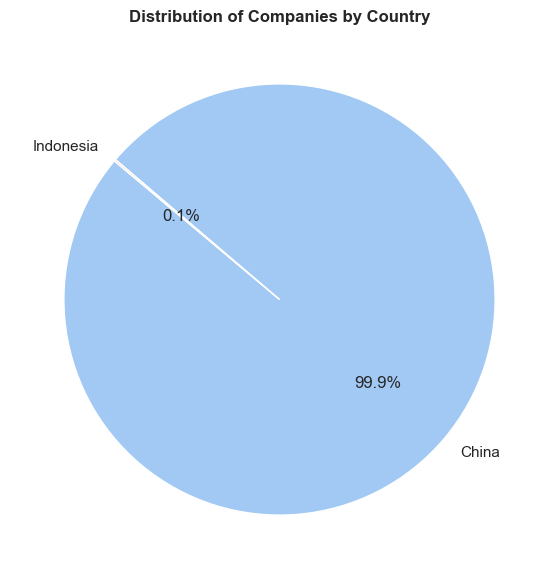

In [81]:
dropped_data['Country'] = dropped_data['Country'].str.strip().str.title()
country_counts = dropped_data['Country'].value_counts()

colors = sns.color_palette('pastel')[0:len(country_counts)]

plt.figure(figsize=(7, 7))
plt.pie(country_counts, 
        labels=country_counts.index, 
        colors=colors,               
        autopct='%.1f%%',           
        startangle=140,
        wedgeprops={'edgecolor': 'white'}) 

plt.title('Distribution of Companies by Country', fontweight='bold')
plt.show()

As mentioned above, we will still keep the `Country` variable even if it's skewed as it still provides valuable input for buyers who are interested in companies in Indonesia.

#### 3.1.2 Entity Type

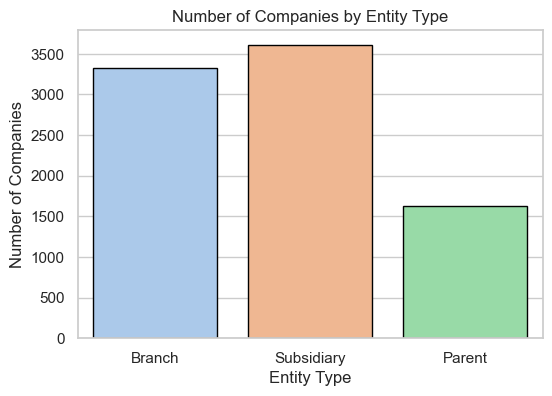

In [82]:
plt.figure(figsize=(6, 4))
sns.countplot(dropped_data, x='Entity Type', palette='pastel', edgecolor='black')
plt.xlabel('Entity Type')
plt.ylabel('Number of Companies')
plt.title('Number of Companies by Entity Type')
plt.show()

#### 3.1.3 Ownership Type

In [83]:
plt.figure(figsize=(10, 4))
sns.countplot(dropped_data, x='Ownership Type', palette='pastel', edgecolor='black')
plt.xlabel('Ownership Type')
plt.ylabel('Number of Companies')
plt.title('Number of Companies by Ownership Type')
plt.show()

ValueError: Could not interpret input 'Ownership Type'

<Figure size 1000x400 with 0 Axes>

In [ ]:
# Count how many companies are in each Ownership Type
ownership_counts = dropped_data['Ownership Type'].value_counts()

# Calculate percentage
ownership_percent = (ownership_counts / ownership_counts.sum()) * 100

# Combine into a table
ownership_table = pd.DataFrame({
    'Count': ownership_counts,
    'Percentage': ownership_percent.round(2)  # round to 2 decimals
})

# Sort by count descending
ownership_table = ownership_table.sort_values(by='Count', ascending=False)
ownership_table

KeyError: 'Ownership Type'

#### 3.1.4 Industry Codes

We use visualizations to determine the most suitable industry code. Industry codes classify companies into sectors, enabling meaningful grouping for analysis and benchmarking. We select the code with the highest data coverage to ensure consistency and completeness in our segmentation.

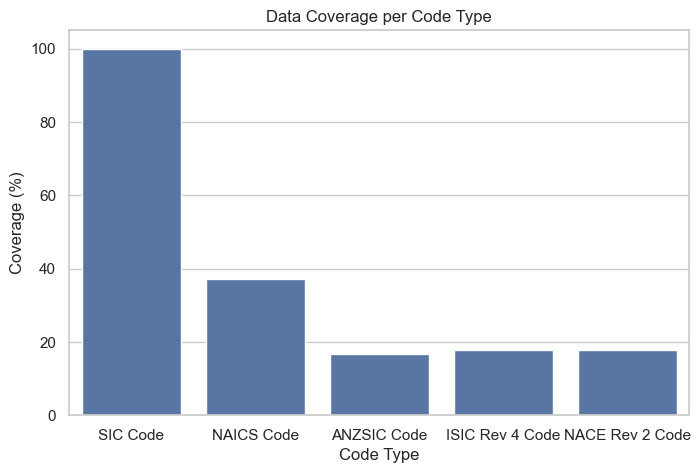

In [ ]:
code_columns = [
    'SIC Code',
    'NAICS Code',
    'ANZSIC Code',
    'ISIC Rev 4 Code',
    'NACE Rev 2 Code'
]

coverage = (1 - data[code_columns].isna().mean()) * 100  # % of non-missing
plt.figure(figsize=(8,5))
sns.barplot(x=coverage.index, y=coverage.values)
plt.ylabel('Coverage (%)')
plt.xlabel('Code Type')
plt.title('Data Coverage per Code Type')
# plt.xticks(rotation=45)
plt.show()


Since SIC Code is 100% populated in the dataset, we will use this instead of the other codes.

#### 3.1.4 Year Found

In [ ]:
bins = list(range(1900, 2030, 10))  # 1900, 1910, ..., 2020
labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

# Creating bins for Year
data['Year_Range'] = pd.cut(data['Year Found'], bins=bins, labels=labels, right=False)
bin_counts = data['Year_Range'].value_counts().sort_index()

# Calculate percentages
bin_percent = (bin_counts / bin_counts.sum()) * 100

# Combine into a table
year_table = pd.DataFrame({
    'Count': bin_counts,
    'Percentage': bin_percent.round(2)
})

year_table

,Count,Percentage
Year_Range,,
1900-1909,1,0.02
1910-1919,0,0.00
1920-1929,0,0.00
1930-1939,0,0.00
1940-1949,2,0.05
1950-1959,23,0.56
1960-1969,7,0.17
1970-1979,10,0.25
1980-1989,126,3.09


#### 3.1.5 Is Headquarters

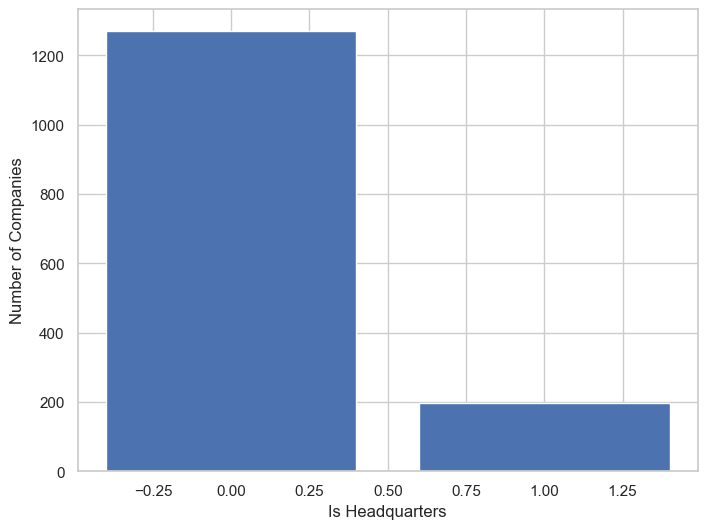

In [ ]:
# Count how many companies are in each category
headquarter_counts = data['Is Headquarters'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(headquarter_counts.index, headquarter_counts.values)
plt.xlabel('Is Headquarters')
plt.ylabel('Number of Companies')
plt.show()

### 3.2 Bivariate Analysis

This explores relationships between 2 variables. We will explore variables that are likely to be related to each other.  

In [ ]:
dropped_data.columns

Index(['DUNS Number ', 'Company Sites', 'Address Line 1', 'City', 'State',
       'State Or Province Abbreviation', 'Postal Code', 'Country',
       'Entity Type', 'Employees Single Site', 'Employees Total',
       'Revenue (USD)', 'SIC Code', 'SIC Description', '8-Digit SIC Code',
       '8-Digit SIC Description', 'NAICS Code', 'NAICS Description',
       'Year Found', 'Parent Company', 'Parent Street Address', 'Parents City',
       'Parent State/Province', 'Parent State/Province Abbreviation',
       'Parent Postal Code', 'Parent Country/Region',
       'Global Ultimate Company', 'Global Ultimate Street Address',
       'Global Ultimate City Name', 'Global Ultimate State/Province',
       'Ultimate State/Province Abbreviation', 'Global Ultimate Postal Code',
       'Domestic Ultimate Company', 'Domestic Ultimate Street Address',
       'Domestic Ultimate City Name', 'Domestic Ultimate State/Province Name',
       'Domestic Ultimate State Abbreviation', 'Domestic Ultimate Postal Code

### 3.2.1 IT Spend & IT Budget

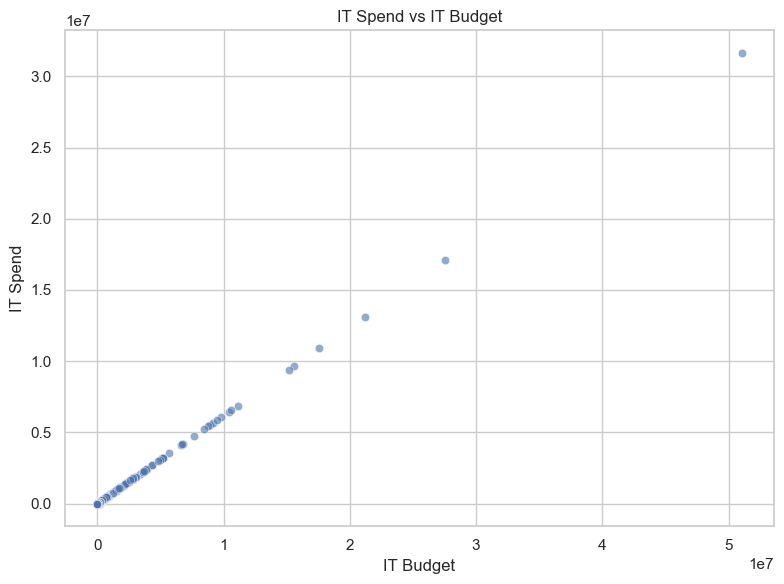

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=dropped_data,
    x="IT Budget",
    y="IT spend",
    alpha=0.6
)

plt.title("IT Spend vs IT Budget")
plt.xlabel("IT Budget")
plt.ylabel("IT Spend")
plt.tight_layout()
plt.show()


The near-diagonal pattern indicates that IT spend increases proportionally with IT budget, suggesting that both variables capture the same underlying scale of IT investment and are therefore largely redundant. Hence, we decided to ......

### 3.2.2 Market Value Vs Revenue

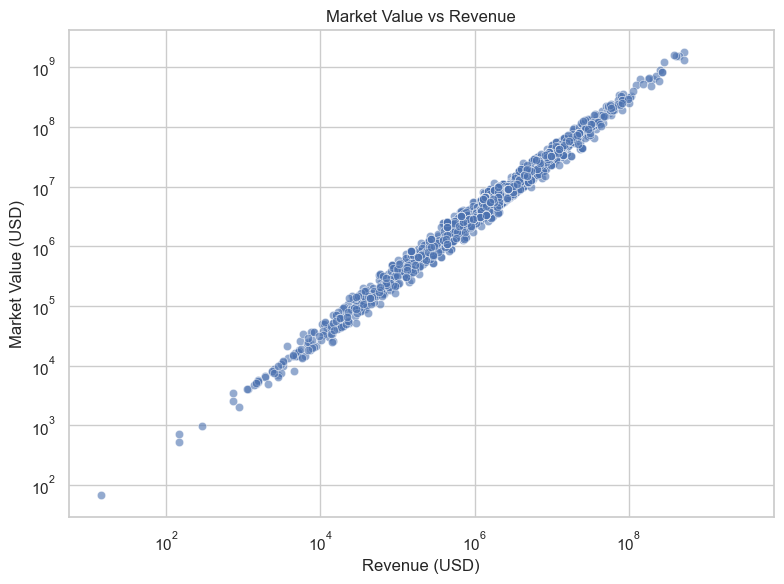

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=dropped_data,
    x="Revenue (USD)",
    y="Market Value (USD)",
    alpha=0.6
)

# Log scale is strongly recommended
plt.xscale("log")
plt.yscale("log")

plt.title("Market Value vs Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Market Value (USD)")
plt.tight_layout()
plt.show()


A logarithmic scale was used because Market Value and Revenue span several orders of magnitude. Applying a log transformation reduces the influence of extreme values, improves interpretability across firms of different sizes, and makes proportional (multiplicative) relationships easier to observe.

Similar to IT Budget and IT Spend, the relationship between Market Value and Revenue is approximately linear, indicating that the two features capture overlapping information. To avoid redundancy,.......

### 3.2.3 Entity Type Vs Employees Single Site

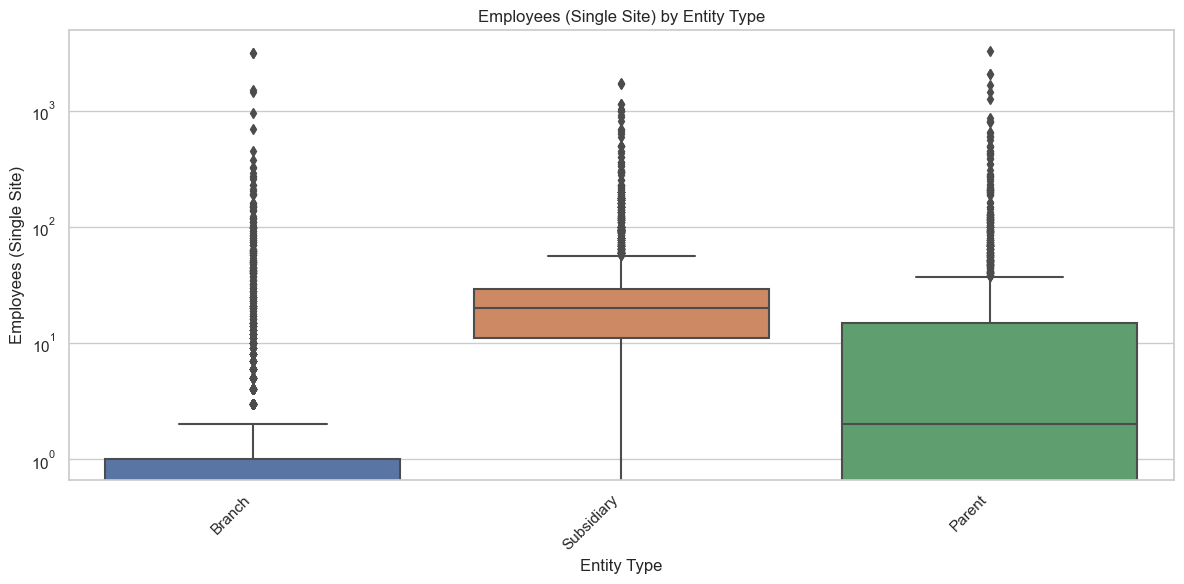

In [ ]:
#boxplot on log scale 

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=dropped_data,
    x="Entity Type",
    y="Employees Single Site"
)

plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("Employees (Single Site) by Entity Type")
plt.ylabel("Employees (Single Site)")
plt.xlabel("Entity Type")
plt.tight_layout()
plt.show()


The boxplot reveals systematic differences in typical site size across entity types, with subsidiaries generally employing more staff per site, while branches are predominantly small but exhibit a long tail of large outliers. This indicates that Employees (Single Site) contains meaningful segmentation signal but is highly right-skewed and heterogeneous.

For clustering purposes, we therefore retain Employees (Single Site) as a feature but apply a logarithmic transformation to reduce the influence of extreme values and ensure that relative differences in site size, rather than absolute counts, drive distance calculations. Entity Type is retained as contextual information rather than a primary size proxy, as substantial overlap exists across categories.

### 3.2.4 Entity Type Vs Employees Single Site

In [ ]:
### 3.2.3 Entity Type Vs Employees Single Site

### 3.3 Multivariate Analysis

### 3.4 Summary Statistics
